In [1]:
import os
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [2]:
file_path = '/Users/SHUNMU/Downloads/mini1/UrbanSound8K.csv'
base_dir = '/Users/SHUNMU/Downloads/mini1'

# Load the CSV data
data = pd.read_csv(file_path)
print(data.head())

      slice_file_name    fsID  start        end  salience  fold  classID  \
0    100032-3-0-0.wav  100032    0.0   0.317551         1     5        3   
1  100263-2-0-117.wav  100263   58.5  62.500000         1     5        2   
2  100263-2-0-121.wav  100263   60.5  64.500000         1     5        2   
3  100263-2-0-126.wav  100263   63.0  67.000000         1     5        2   
4  100263-2-0-137.wav  100263   68.5  72.500000         1     5        2   

              class  
0          dog_bark  
1  children_playing  
2  children_playing  
3  children_playing  
4  children_playing  


Mel-scale matrix for 100032-3-0-0.wav:
 [[-73.46988  -67.18866  -66.366035 ... -76.362915 -76.36308  -73.91464 ]
 [-70.8905   -65.73678  -63.884212 ... -74.68068  -70.7603   -68.844025]
 [-70.472916 -65.01132  -63.53814  ... -64.82889  -64.07271  -61.85409 ]
 ...
 [-80.       -61.949806 -50.580597 ... -71.12569  -72.74367  -78.379524]
 [-80.       -56.22242  -41.48874  ... -67.36104  -70.733086 -76.03682 ]
 [-75.87228  -55.967033 -41.76848  ... -72.65977  -76.80858  -78.18593 ]]


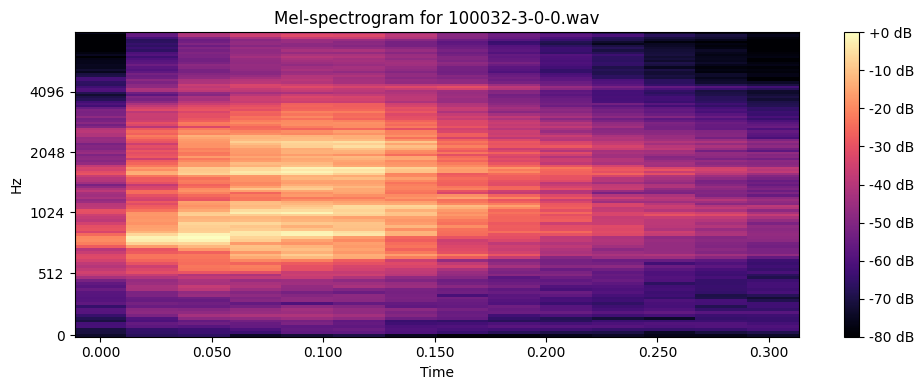

Mel-scale matrix for 100263-2-0-117.wav:
 [[-14.308695  -8.309402 -12.19869  ...  -7.143526 -11.086771 -12.378178]
 [-13.858267  -8.374996 -11.087452 ...  -6.700266 -14.502361 -11.661541]
 [-16.374807 -10.761509 -10.917131 ... -12.637018 -11.177746  -9.956553]
 ...
 [-46.215313 -45.987923 -47.1335   ... -44.536198 -44.744404 -47.16062 ]
 [-49.19177  -46.979343 -47.647015 ... -38.7361   -41.79737  -43.348953]
 [-48.55722  -47.391487 -46.040672 ... -39.419197 -39.43805  -39.100822]]


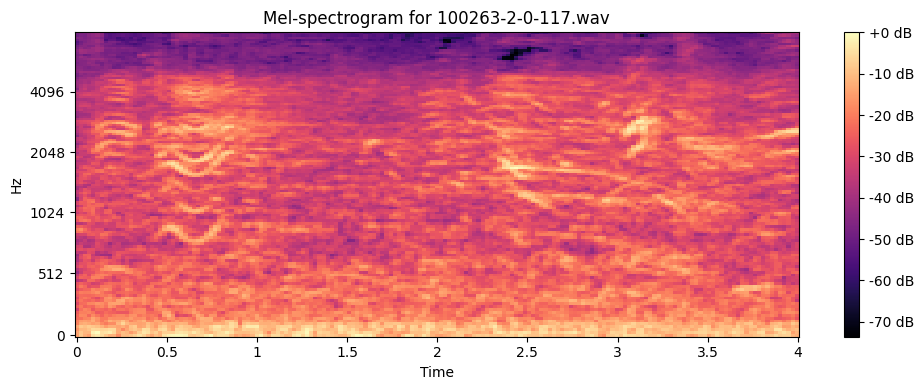

Mel-scale matrix for 100263-2-0-121.wav:
 [[-23.660896  -15.784437   -9.464202  ... -12.001811  -10.044504
  -12.532235 ]
 [-20.69215    -9.94424    -7.988763  ... -16.211123  -13.41894
  -15.395443 ]
 [-15.0264015  -8.983655   -9.968614  ... -14.4704895 -11.686575
  -11.480556 ]
 ...
 [-60.225075  -60.402058  -59.5705    ... -54.96591   -54.804577
  -56.28265  ]
 [-59.23209   -55.981323  -57.440254  ... -56.443455  -59.441013
  -59.084503 ]
 [-57.0686    -55.518322  -56.476154  ... -55.91418   -57.22102
  -56.582767 ]]


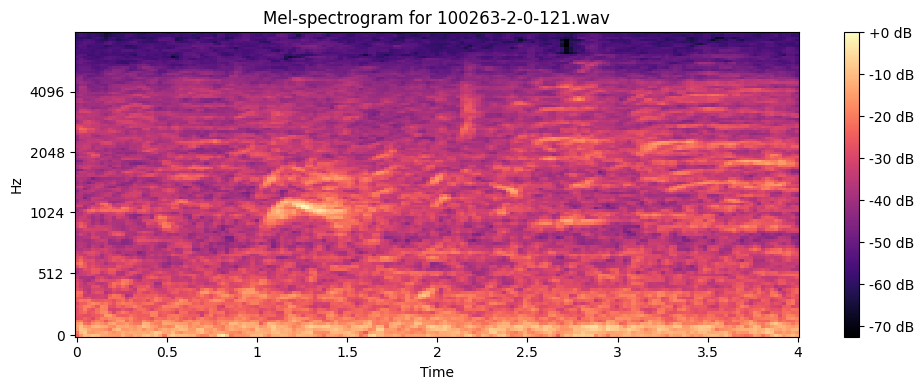

0    [[-73.46988, -67.18866, -66.366035, -74.36304,...
1    [[-14.308695, -8.309402, -12.19869, -14.643091...
2    [[-23.660896, -15.784437, -9.464202, -10.68742...
dtype: object

In [3]:


# Function to extract and print mel-spectrogram features from an audio file
def extract_and_display_mel_spectrogram(row, base_dir):
    # Construct file path using fold and file name
    file_path = os.path.join(base_dir, 'fold' + str(row['fold']), row['slice_file_name'])
    
    # Load audio file
    audio, sample_rate = librosa.load(file_path, res_type='kaiser_fast')
    # Extract Mel-spectrogram
    mel_spectrogram = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=128, fmax=8000)
    
    # Convert to log scale (dB) for better visualization
    mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
    
    # Print the Mel-scale matrix (values)
    print(f"Mel-scale matrix for {row['slice_file_name']}:\n", mel_spectrogram_db)
    
    # Plot the Mel-spectrogram
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mel_spectrogram_db, sr=sample_rate, x_axis='time', y_axis='mel', fmax=8000)
    plt.colorbar(format='%+2.0f dB')
    plt.title(f"Mel-spectrogram for {row['slice_file_name']}")
    plt.tight_layout()
    plt.show()
    
    return mel_spectrogram_db


# Apply Mel-spectrogram extraction and display for the first few files
data.iloc[0:3].apply(lambda row: extract_and_display_mel_spectrogram(row, base_dir), axis=1)

1d cnn

Shape of X_train_1d: (640, 100, 1)
Shape of y_train_encoded: (640, 2)


c:\Users\SHUNMU\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.4495 - loss: 0.7148 - val_accuracy: 0.4563 - val_loss: 0.7508
Epoch 2/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4918 - loss: 0.7029 - val_accuracy: 0.4500 - val_loss: 0.7047
Epoch 3/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5762 - loss: 0.6814 - val_accuracy: 0.4625 - val_loss: 0.6994
Epoch 4/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5915 - loss: 0.6748 - val_accuracy: 0.4250 - val_loss: 0.7069
Epoch 5/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6023 - loss: 0.6680 - val_accuracy: 0.4750 - val_loss: 0.7182
Epoch 6/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6087 - loss: 0.6573 - val_accuracy: 0.4625 - val_loss: 0.7326
Epoch 7/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6038 - loss: 0.6548 - val_accuracy: 0.4750 - val_loss: 0.7319
Epoch 8/10
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6558 - loss: 0.6335 - val_accuracy: 0.4313 - val_

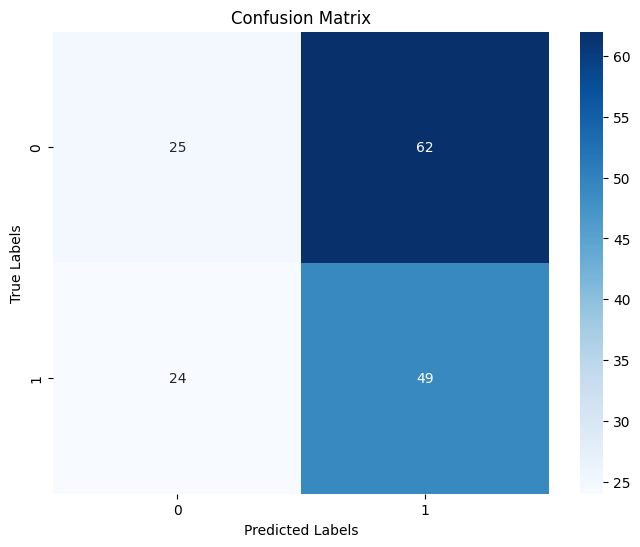

Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.29      0.37        87
           1       0.44      0.67      0.53        73

    accuracy                           0.46       160
   macro avg       0.48      0.48      0.45       160
weighted avg       0.48      0.46      0.44       160



In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming the dataset is loaded and preprocessed here, like your mock data example
X = np.random.rand(800, 100, 1)  # Example feature array with shape (800, 100, 1)
y = np.random.randint(0, 2, size=(800,))  # Example binary labels for 800 samples

# Split the data into training and testing sets
X_train_1d, X_test_1d, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the data
X_train_1d = X_train_1d / np.max(X_train_1d)
X_test_1d = X_test_1d / np.max(X_test_1d)

# One-hot encode labels for multi-class classification
encoder = OneHotEncoder(sparse_output=False)  # Updated for the new version of sklearn
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = encoder.transform(y_test.reshape(-1, 1))

# Check the shapes of the data after reshaping
print(f"Shape of X_train_1d: {X_train_1d.shape}")          # Should be (640, 100, 1)
print(f"Shape of y_train_encoded: {y_train_encoded.shape}") # Should be (640, num_classes)

# Create the 1D CNN model
model = Sequential()
model.add(Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(100, 1)))  # Assuming 100 timesteps and 1 feature
model.add(MaxPooling1D(pool_size=2))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(y_train_encoded.shape[1], activation='softmax'))  # Output layer for multi-class classification

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train_1d, y_train_encoded, epochs=10, batch_size=32, validation_data=(X_test_1d, y_test_encoded))

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test_1d, y_test_encoded)
print(f'1D CNN Test Accuracy: {test_accuracy}')

# Predicting labels for the test data
y_pred = model.predict(X_test_1d)

# Converting predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_encoded, axis=1)

# Confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
print('Confusion Matrix:')
print(conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Classification report
class_report = classification_report(y_true_classes, y_pred_classes)
print('Classification Report:')
print(class_report)


Shape of X_train_1d: (640, 100, 1)
Shape of y_train_encoded: (640, 2)


c:\Users\SHUNMU\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 17s 97ms/step - accuracy: 0.5046 - loss: 1.3563 - val_accuracy: 0.4938 - val_loss: 0.7470
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.4740 - loss: 1.0419 - val_accuracy: 0.4938 - val_loss: 1.1212
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5222 - loss: 0.8567 - val_accuracy: 0.4938 - val_loss: 1.5536
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.5233 - loss: 0.7906 - val_accuracy: 0.4938 - val_loss: 1.8373
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.5369 - loss: 0.8312 - val_accuracy: 0.4938 - val_loss: 2.1038
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5224 - loss: 0.8078 - val_accuracy: 0.4938 - val_loss: 2.1202
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5290 - loss: 0.7596 - val_accuracy: 0.4938 - val_loss: 1.9926
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.5545 - loss: 0.7330 - val_accuracy: 0

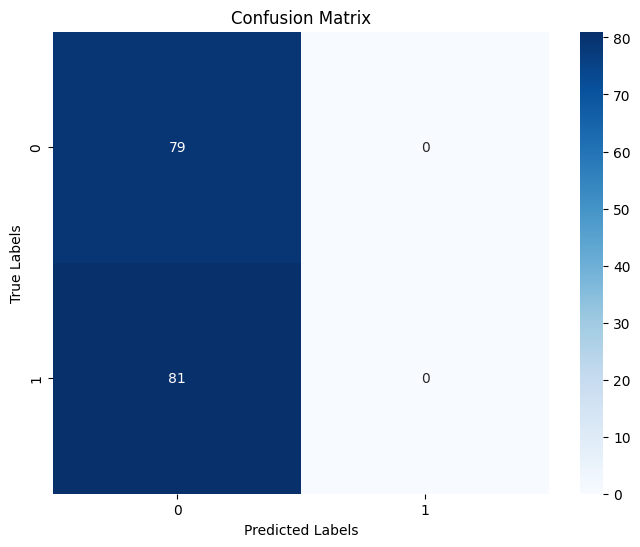

Classification Report:
              precision    recall  f1-score   support

           0       0.49      1.00      0.66        79
           1       0.00      0.00      0.00        81

    accuracy                           0.49       160
   macro avg       0.25      0.50      0.33       160
weighted avg       0.24      0.49      0.33       160



c:\Users\SHUNMU\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SHUNMU\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\SHUNMU\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

In [14]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from keras.models import Sequential
from keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming the dataset is loaded and preprocessed here, like your mock data example
X = np.random.rand(800, 100, 1)  # Example feature array with shape (800, 100, 1)
y = np.random.randint(0, 2, size=(800,))  # Example binary labels for 800 samples

# Split the data into training and testing sets
X_train_1d, X_test_1d, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the data
X_train_1d = X_train_1d / np.max(X_train_1d)
X_test_1d = X_test_1d / np.max(X_test_1d)

# One-hot encode labels for multi-class classification
encoder = OneHotEncoder(sparse_output=False)  # Updated for the new version of sklearn
y_train_encoded = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_encoded = encoder.transform(y_test.reshape(-1, 1))

# Check the shapes of the data after reshaping
print(f"Shape of X_train_1d: {X_train_1d.shape}")          # Should be (640, 100, 1)
print(f"Shape of y_train_encoded: {y_train_encoded.shape}") # Should be (640, num_classes)

# Create the 1D CNN model
model = Sequential()

# First Convolutional Layer
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(100, 1)))
model.add(BatchNormalization())  # Added Batch Normalization
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))  # Added Dropout for regularization

# Second Convolutional Layer
model.add(Conv1D(filters=128, kernel_size=3, activation='relu'))
model.add(BatchNormalization())  # Added Batch Normalization
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.4))  # Added Dropout for regularization

# Third Convolutional Layer (optional, to increase complexity)
model.add(Conv1D(filters=256, kernel_size=3, activation='relu'))
model.add(BatchNormalization())  # Added Batch Normalization
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.5))  # Further dropout to avoid overfitting

# Flatten the output from the Conv layers
model.add(Flatten())

# Dense Layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))  # Added Dropout for regularization
model.add(Dense(64, activation='relu'))

# Output layer
model.add(Dense(y_train_encoded.shape[1], activation='softmax'))  # Multi-class output

# Compile the model with Adam optimizer and lower learning rate
optimizer = Adam(learning_rate=0.0003)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train the model with early stopping
history = model.fit(X_train_1d, y_train_encoded, epochs=100, batch_size=32, 
                    validation_data=(X_test_1d, y_test_encoded), callbacks=[early_stopping])

# Evaluate the model on test data
test_loss, test_accuracy = model.evaluate(X_test_1d, y_test_encoded)
print(f'1D CNN Test Accuracy: {test_accuracy}')

# Predicting labels for the test data
y_pred = model.predict(X_test_1d)

# Converting predictions to class labels
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_encoded, axis=1)

# Confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
print('Confusion Matrix:')
print(conf_matrix)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Classification report
class_report = classification_report(y_true_classes, y_pred_classes)
print('Classification Report:')
print(class_report)


2D CNN

In [ ]:
# Train 2D CNN
history_2d = model_2d.fit(X_train_2d, y_train, epochs=10, batch_size=32, validation_data=(X_test_2d, y_test))

# Predict on test data
y_pred_2d = model_2d.predict(X_test_2d)
y_pred_2d = np.round(y_pred_2d).astype(int)

# Calculate accuracy, confusion matrix, precision, recall, F1 score
accuracy_2d = accuracy_score(y_test, y_pred_2d)
conf_matrix_2d = confusion_matrix(y_test, y_pred_2d)
precision_2d = precision_score(y_test, y_pred_2d)
recall_2d = recall_score(y_test, y_pred_2d)
f1_2d = f1_score(y_test, y_pred_2d)

# Print the results
print(f"2D-CNN Accuracy: {accuracy_2d:.4f}")
print(f"Confusion Matrix:\n{conf_matrix_2d}")
print(f"Precision: {precision_2d:.4f}")
print(f"Recall: {recall_2d:.4f}")
print(f"F1 Score: {f1_2d:.4f}")
